<a href="https://colab.research.google.com/github/mundevaishnavi13/Artificial_Intelligence_Lab_SE_A_42/blob/master/ds9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


Load Dataset

In [4]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Check and Prepare Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Convert Date column:

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

To check null values


In [21]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0
Month,0


Remove missing values:

In [7]:
df = df.dropna()

Count Total Duplicate Rows

In [22]:
df.duplicated().sum()

np.int64(0)

Total Sales

In [8]:
total_sales = df['Total Amount'].sum()
print("Total Sales:", total_sales)

Total Sales: 456000


Total Units Sold

In [9]:
total_units = df['Quantity'].sum()
print("Total Units Sold:", total_units)

Total Units Sold: 2514


 Create Month Column

In [10]:
df['Month'] = df['Date'].dt.to_period('M')

check top products


In [20]:
display(top_products)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


To check columns

In [23]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month'],
      dtype='object')


Top 5 Best-Selling Products Based on Total Sales Revenue

Top 5 Products by Sales:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


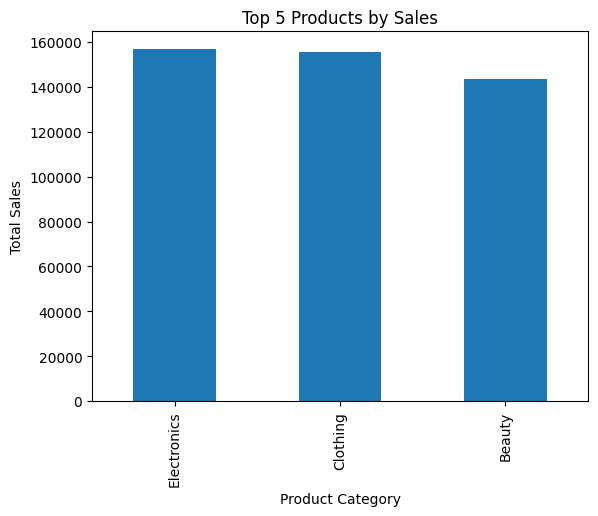

In [17]:
top_products = df.groupby('Product Category')['Total Amount'].sum().nlargest(5)

# Show data
print("Top 5 Products by Sales:")
print(top_products)

# Plot graph
top_products.plot(kind='bar')
plt.title("Top 5 Products by Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

Sales Distribution Across Different Product Categories

Sales by Product Category:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


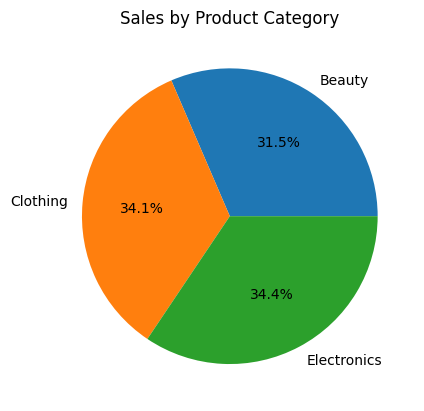

In [18]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

# Show data
print("Sales by Product Category:")
print(category_sales)

# Plot graph
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Product Category")
plt.ylabel("")
plt.show()

Monthly Sales Trend Analysis of the Retail Company

Monthly Sales Trend:
Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


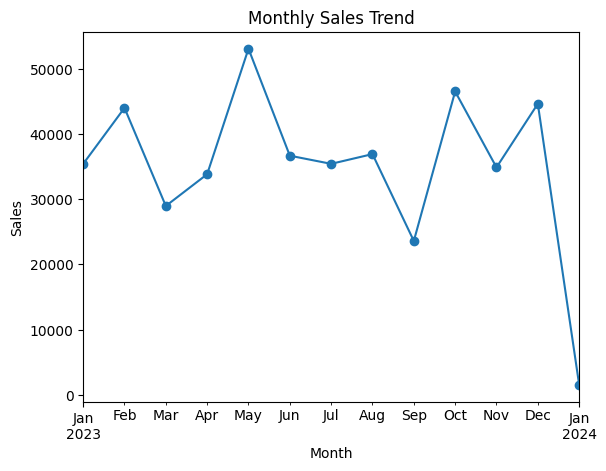

In [19]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Show data
print("Monthly Sales Trend:")
print(monthly_sales)

# Plot graph
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()